In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

from DiffusionModel import *

import matplotlib as mpl
import matplotlib.pyplot as plt
import pickle as pkl

from tqdm import tqdm
import os
from copy import deepcopy
import time

from scipy.spatial import Delaunay

from fit_utils import *

In [2]:
# device = 'cuda' if torch.cuda.is_available() else 'cpu'
device = 'cpu'
device

'cpu'

In [3]:
model = DiffusionModel() # .load('diffusion_model.pt',compiled=True)
sum(p.numel() for p in model.parameters() if p.requires_grad)

5390

depth: 2


100%|██████████| 250/250 [04:29<00:00,  1.08s/it, l_T=78.7, rel=0.00285]


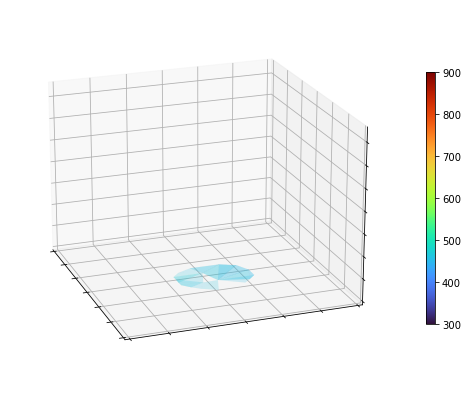

parameters:
Parameter containing:
tensor([-0.9772, -0.9775, -1.0000], requires_grad=True)
50.0, 0.4000000059604645
depth: 5


100%|██████████| 100/100 [05:01<00:00,  3.01s/it, l_T=79.2, rel=0.00812]


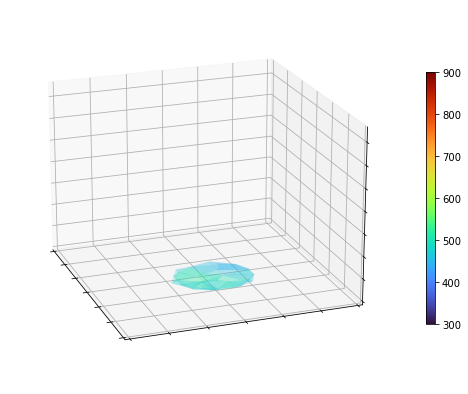

parameters:
Parameter containing:
tensor([-0.9581, -0.9567, -0.9822], requires_grad=True)
50.0, 0.4000000059604645
depth: 10


100%|██████████| 50/50 [06:19<00:00,  7.60s/it, l_T=78.4, rel=0.0188]


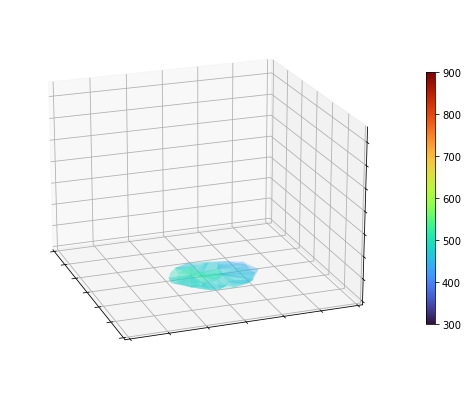

parameters:
Parameter containing:
tensor([-0.9384, -0.9344, -0.9608], requires_grad=True)
50.00038146972656, 0.3995007872581482
depth: 25


100%|██████████| 25/25 [00:17<00:00,  1.47it/s, l_T=125, rel=-.73, l_reg=2.45, l_E=0.207, t_min=182, t_max=827]       


105.2720769343794 -0.20245213290498487


100%|██████████| 25/25 [00:16<00:00,  1.54it/s, l_T=127, rel=-.751, l_reg=2.42, l_E=0.209, t_min=182, t_max=833]       


128.0566502330557 -0.4627049896753633


...

98.94992133051267 -0.13023840147869722


100%|██████████| 25/25 [00:17<00:00,  1.45it/s, l_T=83.6, rel=-.154, l_reg=2.1, l_E=0.218, t_min=104, t_max=796]      


98.10439836779429 -0.12058056134152012


100%|██████████| 25/25 [00:16<00:00,  1.48it/s, l_T=81.2, rel=-.12, l_reg=2.09, l_E=0.22, t_min=101, t_max=785]       


97.19158380161798 -0.11015409447576582


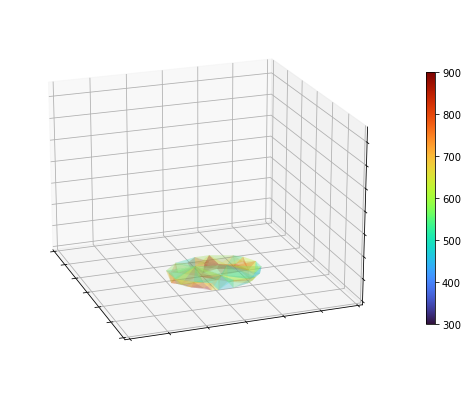

parameters:
Parameter containing:
tensor([-0.9167, -0.9112, -0.9378], requires_grad=True)
50.00053405761719, 0.39930054545402527
depth: 50


100%|██████████| 50/50 [00:49<00:00,  1.01it/s, l_T=80.2, rel=-.717, l_reg=132, l_E=96.4, t_min=141, t_max=811]       


87.8405551935004 -0.1629258937169582


100%|██████████| 50/50 [00:49<00:00,  1.00it/s, l_T=57, rel=-.219, l_reg=132, l_E=94.9, t_min=154, t_max=703]         


79.0020228432098 -0.04591208261380965


...

75.17593880738713 0.0047416522925073255


100%|██████████| 50/50 [00:47<00:00,  1.06it/s, l_T=47.3, rel=-.0118, l_reg=132, l_E=92.5, t_min=105, t_max=670]       


75.49170977563 0.0005611432480824801


100%|██████████| 50/50 [00:47<00:00,  1.04it/s, l_T=46.8, rel=-.00158, l_reg=132, l_E=89.2, t_min=66.4, t_max=644]     


75.27656277511034 0.0034094861041665354


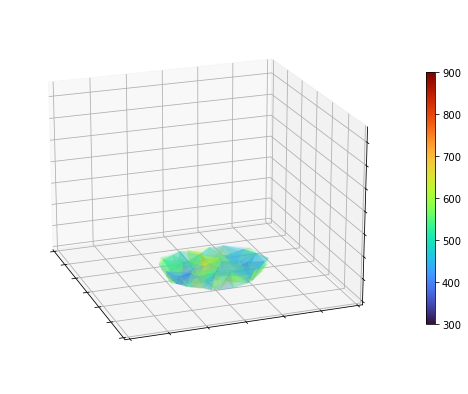

parameters:
Parameter containing:
tensor([-0.8933, -0.8868, -0.9132], requires_grad=True)
50.0006103515625, 0.3992004096508026
depth: 100


100%|██████████| 100/100 [02:57<00:00,  1.78s/it, l_T=36.1, rel=-.0307, l_reg=19.9, l_E=6.06, t_min=76.2, t_max=343]    


63.25098424322371 0.0016240588153320034


100%|██████████| 100/100 [02:46<00:00,  1.66s/it, l_T=35.4, rel=-.0108, l_reg=19.9, l_E=4.73, t_min=99.9, t_max=249]    


63.241721556387866 0.0017702643455428156


...

63.42628236529378 -0.0011429088406434368


100%|██████████| 100/100 [02:47<00:00,  1.68s/it, l_T=35.1, rel=-.00406, l_reg=19.8, l_E=17.1, t_min=168, t_max=405]   


63.947529547827855 -0.009370459015217387


100%|██████████| 100/100 [02:47<00:00,  1.68s/it, l_T=34.8, rel=0.00541, l_reg=19.8, l_E=5.39, t_min=180, t_max=327]   


63.909357177030635 -0.008767932792457349


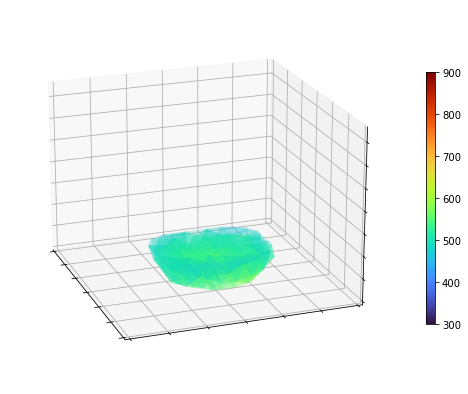

parameters:
Parameter containing:
tensor([-0.8648, -0.8576, -0.8839], requires_grad=True)
50.000648498535156, 0.3991503417491913
depth: 250


100%|██████████| 250/250 [19:11<00:00,  4.60s/it, l_T=22.5, rel=-.0199, l_reg=13.8, l_E=2.4, t_min=0, t_max=328]      


69.77673165105529 -0.005587789401839357


100%|██████████| 250/250 [18:58<00:00,  4.55s/it, l_T=21.9, rel=0.00876, l_reg=13.8, l_E=2.51, t_min=0, t_max=329]      


69.48606455693984 -0.001398838820359949


100%|██████████| 250/250 [19:00<00:00,  4.56s/it, l_T=21.7, rel=0.0161, l_reg=13.8, l_E=2.63, t_min=0, t_max=329]       


68.9631922522529 0.0061365385549951605


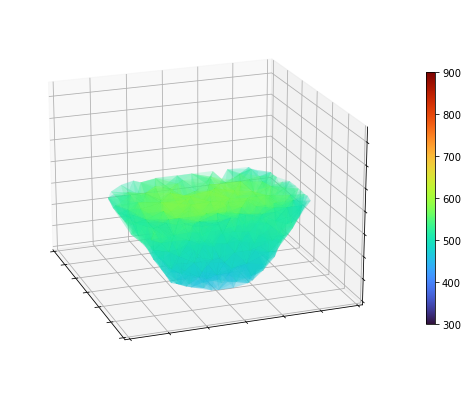

parameters:
Parameter containing:
tensor([-0.8102, -0.8027, -0.8288], requires_grad=True)
50.000728607177734, 0.3990606963634491
depth: 500


100%|██████████| 500/500 [1:17:54<00:00,  9.35s/it, l_T=59.8, rel=0.0537, l_reg=7.95, l_E=0.446, t_min=0, t_max=619]    


102.18897180498752 0.020305135647800027
saving model state.


100%|██████████| 500/500 [1:18:23<00:00,  9.41s/it, l_T=61.1, rel=0.0331, l_reg=7.92, l_E=0.44, t_min=0, t_max=618]     


102.73929816858701 0.015029107299408987


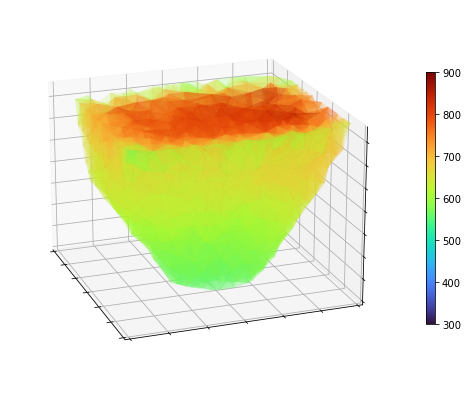

parameters:
Parameter containing:
tensor([-0.7547, -0.7465, -0.7724], requires_grad=True)
50.001068115234375, 0.39906635880470276


In [4]:
hist = fit_model(model, 
                 alpha_conn=.1, 
                 alpha_diss=.1, 
                 alpha_energy= 10, 
                 alpha_heat= .1, 
                 alpha_max_min= 10,
                 save_best=True,
                 lr=1e-6,
                 betas=(.5,.99),
                 save_path='models/compare_explicit_low_lr.pt')

  1%|          | 4/500 [00:00<00:41, 11.87it/s, corr=0.382]

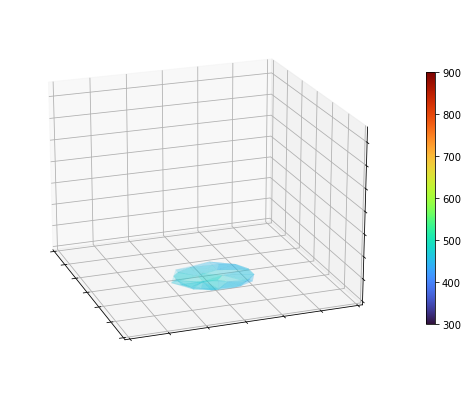

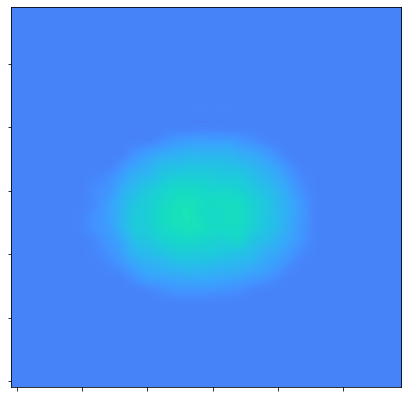

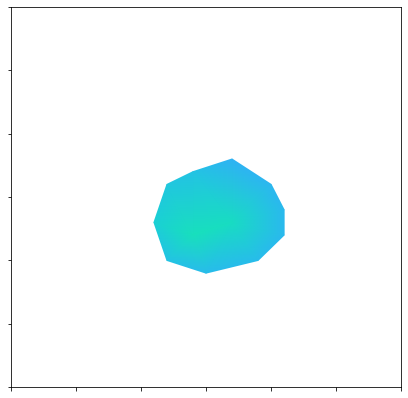

  2%|▏         | 8/500 [00:01<01:21,  6.04it/s, corr=0.355]

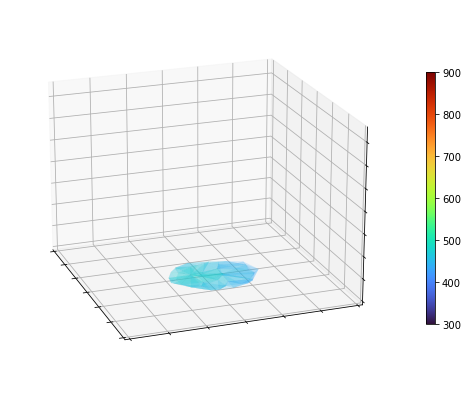

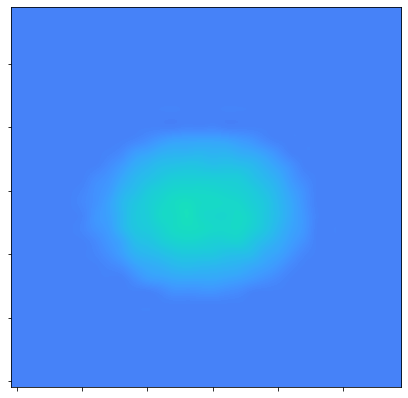

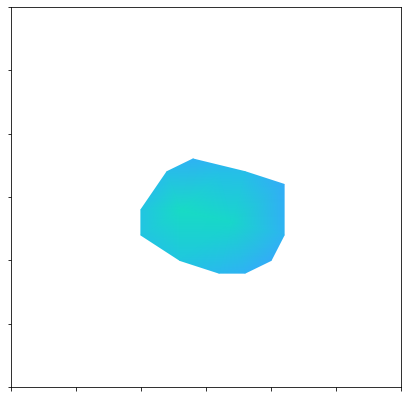

  5%|▍         | 24/500 [00:03<00:38, 12.37it/s, corr=0.313]

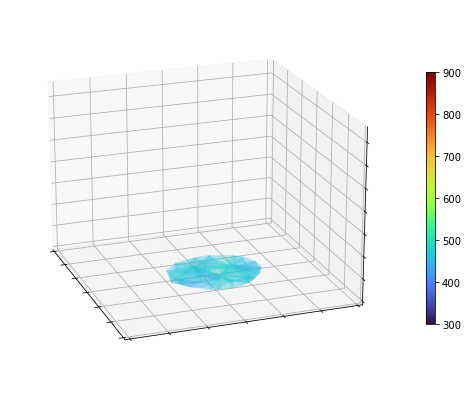

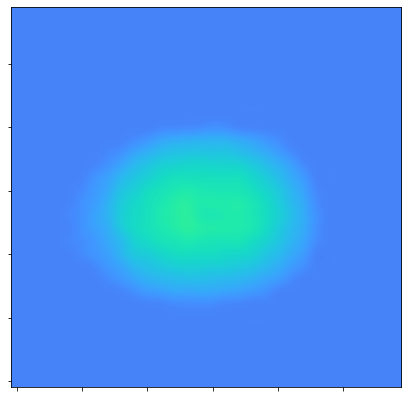

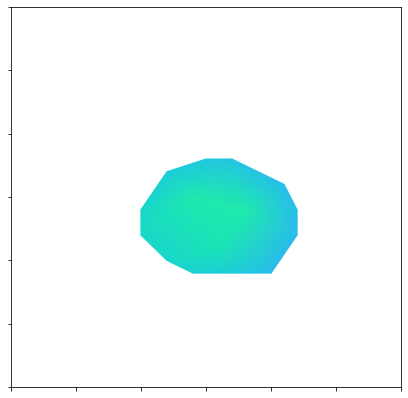

 10%|▉         | 49/500 [00:06<00:53,  8.48it/s, corr=0.417]

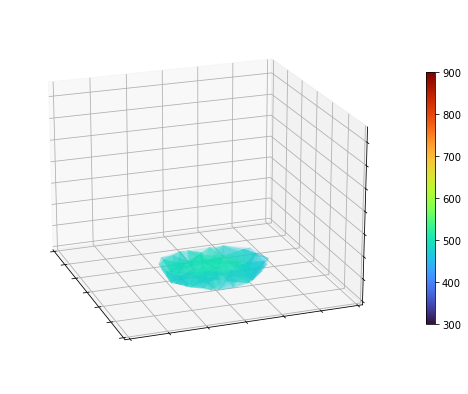

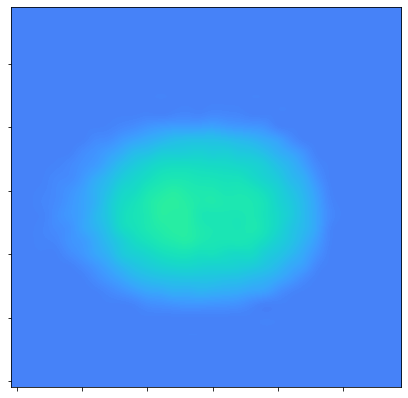

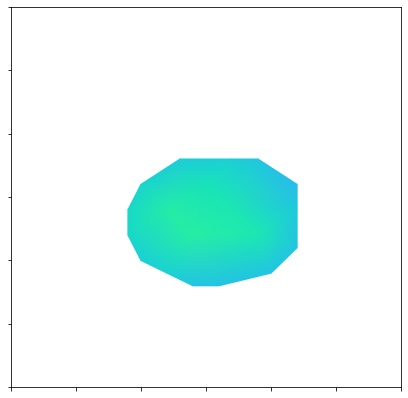

 20%|█▉        | 99/500 [00:15<01:29,  4.50it/s, corr=0.267]

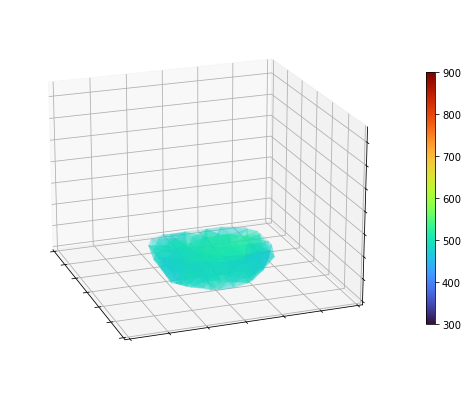

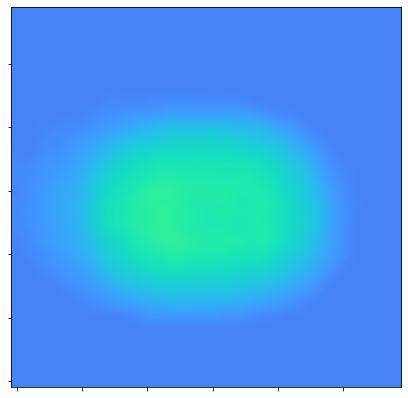

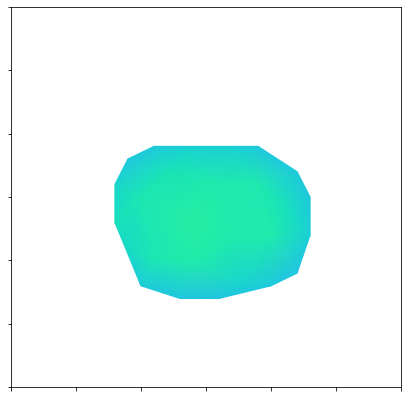

 30%|██▉       | 149/500 [00:27<01:33,  3.77it/s, corr=0.272]

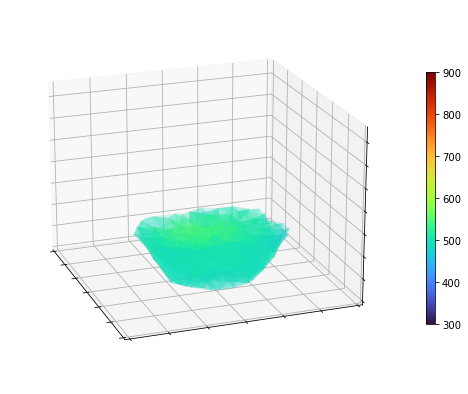

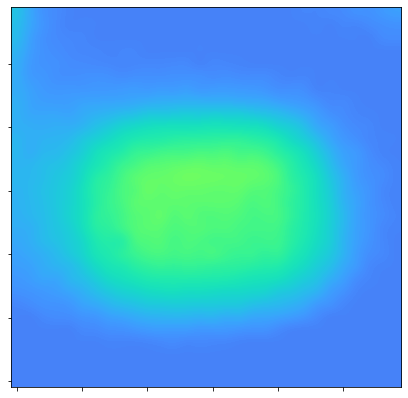

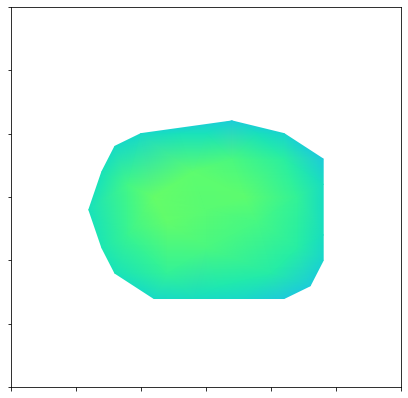

 40%|███▉      | 199/500 [00:45<01:58,  2.54it/s, corr=0.324] 

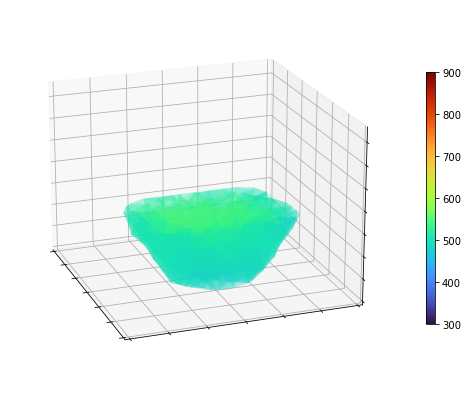

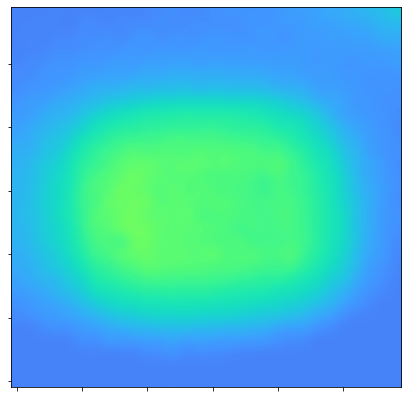

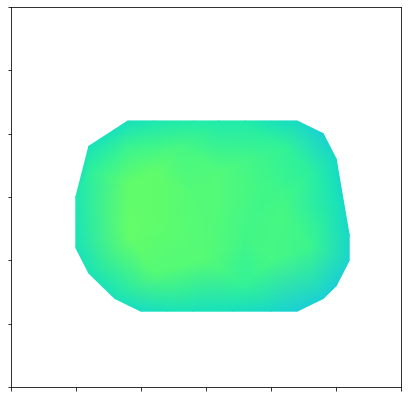

 50%|████▉     | 249/500 [01:05<01:41,  2.48it/s, corr=0.341]

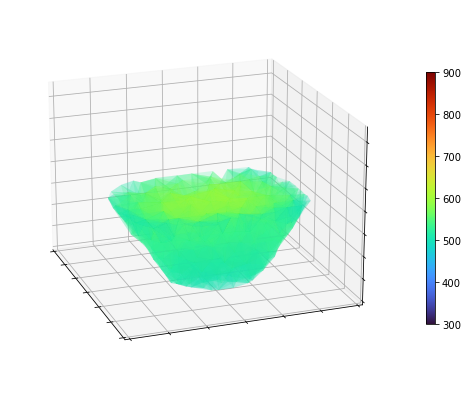

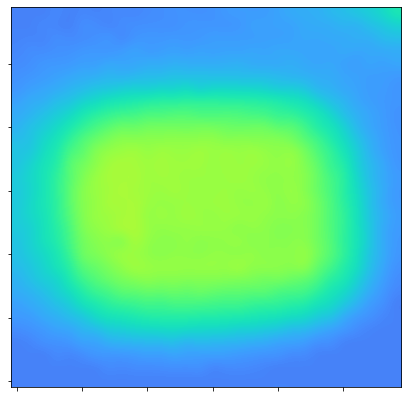

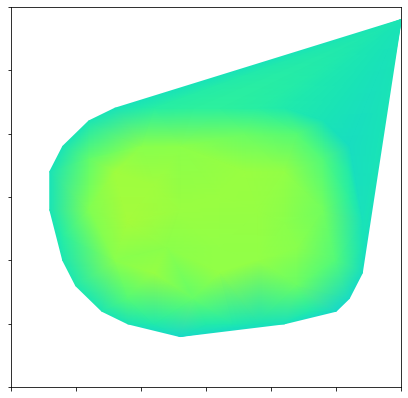

 60%|█████▉    | 299/500 [01:28<01:27,  2.29it/s, corr=0.304]

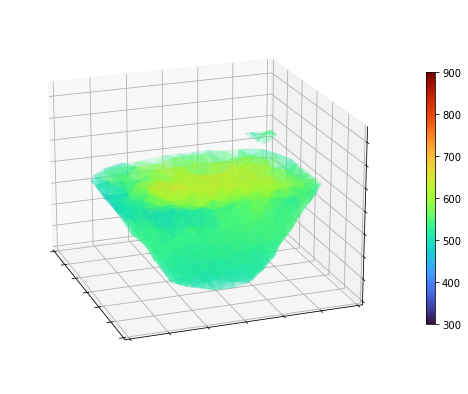

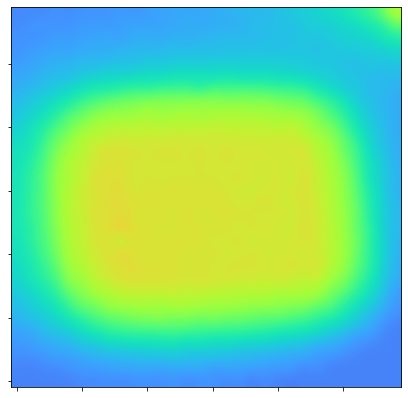

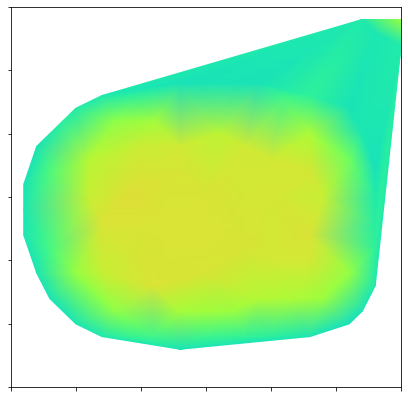

 70%|██████▉   | 349/500 [02:00<01:48,  1.39it/s, corr=0.238]

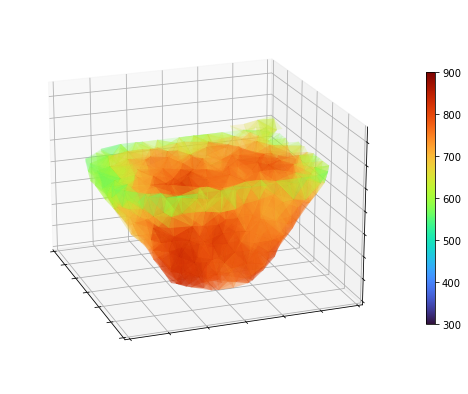

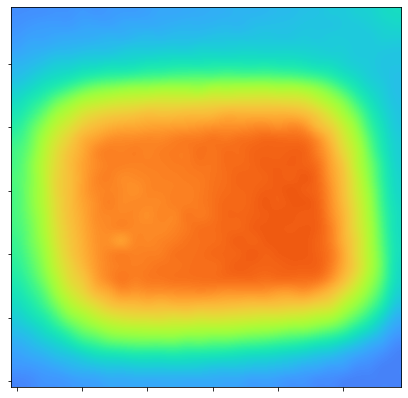

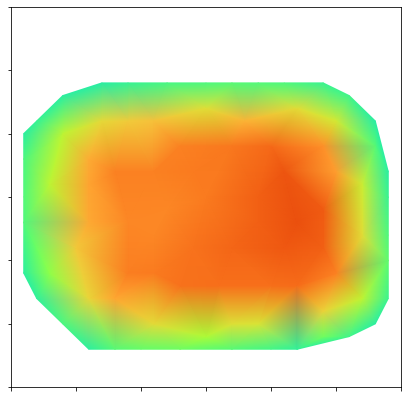

 80%|███████▉  | 399/500 [02:45<01:37,  1.03it/s, corr=0.117]

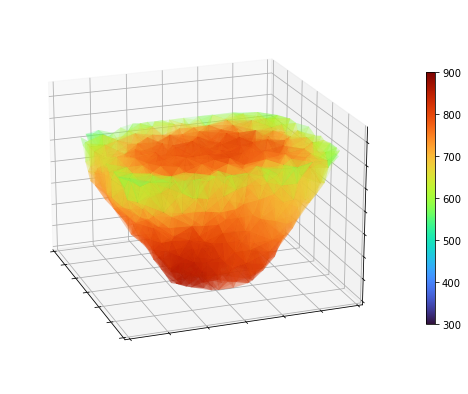

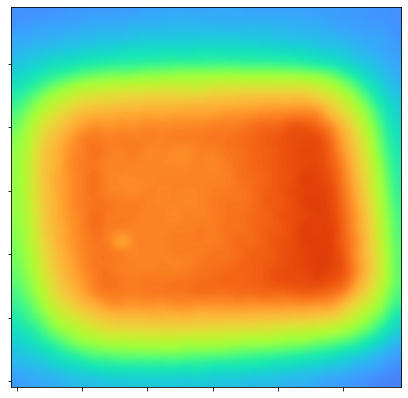

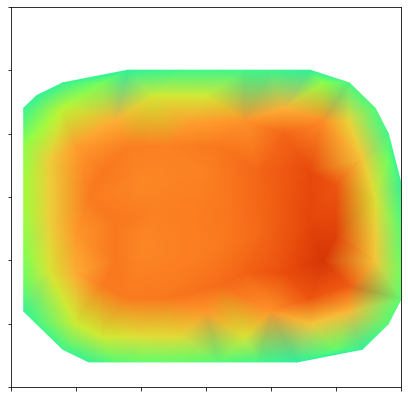

 90%|████████▉ | 449/500 [03:46<01:02,  1.22s/it, corr=0.136] 

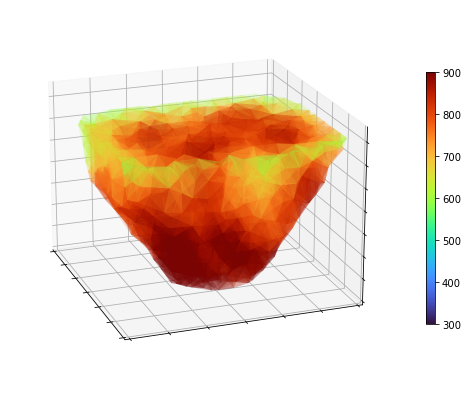

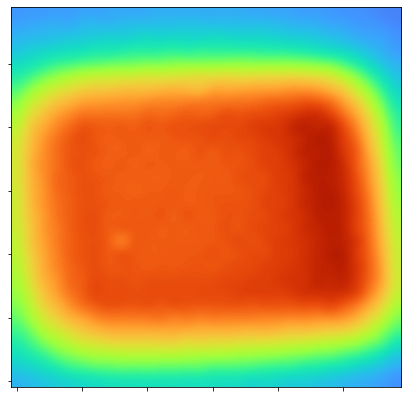

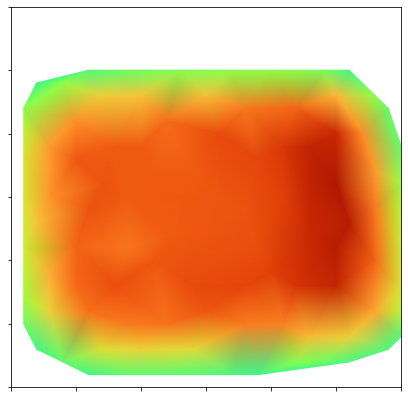

100%|█████████▉| 499/500 [04:59<00:01,  1.42s/it, corr=0.146] 

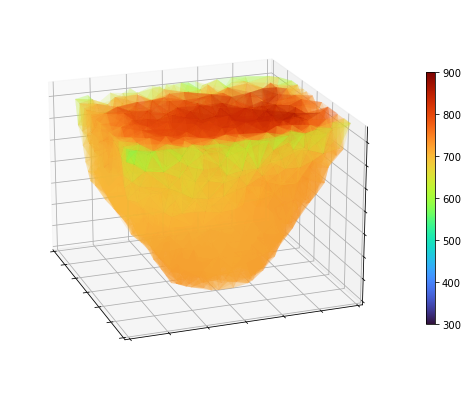

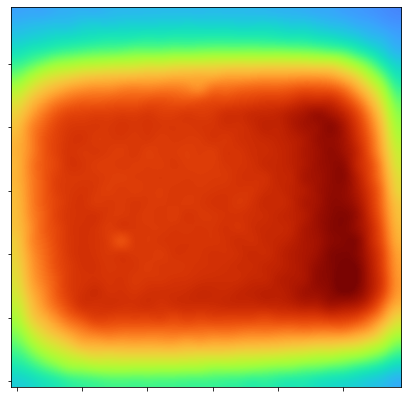

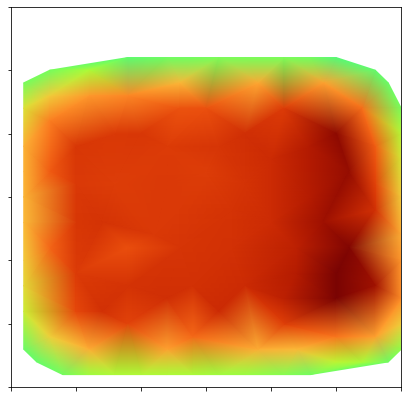

100%|██████████| 500/500 [05:04<00:00,  1.64it/s, corr=0.146]


In [5]:
correlations = develop_layers(model,plot_dir='./plots/explicit_model_low_lr')

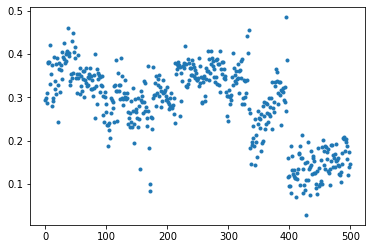

In [6]:
plt.scatter(np.arange(len(correlations)),correlations,marker='.')
plt.savefig('correlations.svg',bbox_inches='tight',format='svg')
plt.show()